In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
FFT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_FFT\images\angles.csv"
HOUGH_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_hough2\images\angles.csv"
GT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\labels.csv"
CNN_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_cnn\angles.csv"

In [19]:
FFT_df= pd.read_csv(FFT_ROOT)
HOUGH_df= pd.read_csv(HOUGH_ROOT)
GT_df = pd.read_csv(GT_ROOT)
CNN_df = pd.read_csv(CNN_ROOT)

FFT_df.describe(),HOUGH_df.describe(),GT_df.describe(),CNN_df.describe()

(       fringe_angle_deg  rotation_deg
 count       1000.000000   1000.000000
 mean          -1.317917     -0.662083
 std           51.276557     53.086430
 min          -89.719322    -89.834437
 25%          -43.551293    -48.114648
 50%           -1.860337     -1.508397
 75%           41.595655     46.933151
 max           89.815186     89.997270,
        fringe_angle_deg  vertical_error_deg  rotation_deg
 count       1000.000000         1000.000000   1000.000000
 mean          -2.411136           -2.088864      2.088864
 std           50.555764           53.401416     53.401416
 min          -89.972659          -90.000000    -89.991337
 25%          -44.309079          -48.408634    -45.359045
 50%           -2.863145           -3.483740      3.483740
 75%           40.514882           45.359045     48.408634
 max           89.799150           89.991337     90.000000,
          angle_deg    n_fringes
 count  1000.000000  1000.000000
 mean     46.792901    17.613607
 std      51.7631

In [20]:
FFT_angles = FFT_df['rotation_deg'].values
HOUGH_angles = HOUGH_df['rotation_deg'].values
GT_angles = GT_df['angle_deg'].values
CNN_angles = CNN_df['predicted_angle'].values

In [21]:
FFT_angles,HOUGH_angles,GT_angles,CNN_angles

(array([-84.6573864 , -56.47226933,  33.43211384,  12.15790111,
        -50.84299555, -10.11363173,  38.29055048,  56.34551422,
         33.02884536, -56.87030181, -23.9023069 , -83.87878203,
        -29.67424888, -75.93519223,  63.58046677,  27.68162865,
        -75.58128363,  -6.04544615, -72.8744312 , -52.86986818,
         48.44934316,  58.8586142 , -71.84917832,  88.4082732 ,
        -54.8678858 ,  18.87038655, -26.75156025,  62.24401981,
         -5.7199013 ,  -6.60108908, -50.76896295, -81.56688083,
        -67.90347462, -69.84941948, -39.43764162,  -4.32031308,
         58.59780322,  10.12969337, -44.43230544,  70.90788927,
          6.69165475,   1.8701686 ,  48.26292416,  60.92489715,
         25.59268466,  60.88681438, -37.28724908,  27.24576858,
         88.87193626, -69.43753006, -14.78311816, -19.98854832,
         53.60401857, -79.66860637, -49.10920729, -20.61362009,
         46.03981558,   6.89742912,  -0.90298583, -61.98151336,
         10.07898492,  42.69677255,  70.

In [22]:
import numpy as np
from sklearn.metrics import r2_score

def angular_error(pred, gt):
    """
    Circular angular error for orientations.
    Returns error in [-90, 90) degrees.
    """
    return (pred - gt + 90) % 180 - 90

In [23]:
def evaluate(pred, gt, name="Method"):
    err = angular_error(np.asarray(pred), np.asarray(gt))

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    median = np.median(np.abs(err))
    std = np.std(err)

    within_05 = np.mean(np.abs(err) <= 0.5) * 100
    within_1 = np.mean(np.abs(err) <= 1.0) * 100
    within_2 = np.mean(np.abs(err) <= 2.0) * 100
    within_5 = np.mean(np.abs(err) <= 5.0) * 100

    # Circularly corrected prediction for R²
    pred_corrected = gt + err
    r2 = r2_score(gt, pred_corrected)

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE            : {mae:.3f}°")
    print(f"RMSE           : {rmse:.3f}°")
    print(f"Median Error   : {median:.3f}°")
    print(f"Std Error      : {std:.3f}°")
    print(f"R² Score       : {r2:.5f}")
    print(f"Within 0.5°    : {within_05:.2f}%")
    print(f"Within 1°      : {within_1:.2f}%")
    print(f"Within 2°      : {within_2:.2f}%")
    print(f"Within 5°      : {within_5:.2f}%")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Median": median,
        "Std": std,
        "R2": r2,
        "Within0.5": within_05,
        "Within1": within_1,
        "Within2": within_2,
        "Within5": within_5,
    }

In [24]:
fft_metrics = evaluate(FFT_angles, GT_angles, "FFT")
hough_metrics = evaluate(HOUGH_angles, GT_angles, "HOUGH")
CNN_metrics = evaluate(CNN_angles, GT_angles, "CNN")


FFT
----------------------------------------
MAE            : 44.451°
RMSE           : 51.701°
Median Error   : 44.072°
Std Error      : 51.684°
R² Score       : 0.00140
Within 0.5°    : 0.40%
Within 1°      : 1.10%
Within 2°      : 1.70%
Within 5°      : 5.90%

HOUGH
----------------------------------------
MAE            : 1.332°
RMSE           : 6.195°
Median Error   : 0.165°
Std Error      : 6.194°
R² Score       : 0.98566
Within 0.5°    : 78.00%
Within 1°      : 84.60%
Within 2°      : 89.70%
Within 5°      : 95.50%

CNN
----------------------------------------
MAE            : 1.076°
RMSE           : 2.171°
Median Error   : 0.606°
Std Error      : 2.168°
R² Score       : 0.99824
Within 0.5°    : 43.50%
Within 1°      : 68.00%
Within 2°      : 88.60%
Within 5°      : 97.50%


In [36]:
err_Hough=angular_error(HOUGH_angles, GT_angles)
err_FFT=angular_error(FFT_angles, GT_angles)
err_CNN=angular_error(CNN_angles, GT_angles)

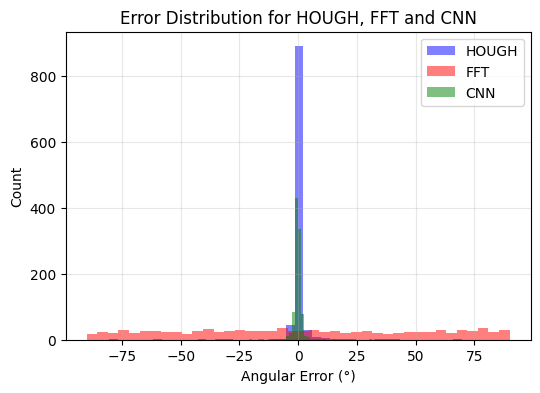

In [28]:
plt.figure(figsize=(6,4))
plt.hist(err_Hough, bins=40, alpha=0.5, label='HOUGH', color='blue')
plt.hist(err_FFT, bins=40, alpha=0.5, label='FFT', color='red')
plt.hist(err_CNN, bins=40, alpha=0.5, label='CNN', color='green')
plt.xlabel("Angular Error (°)")
plt.ylabel("Count")
plt.title("Error Distribution for HOUGH, FFT and CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

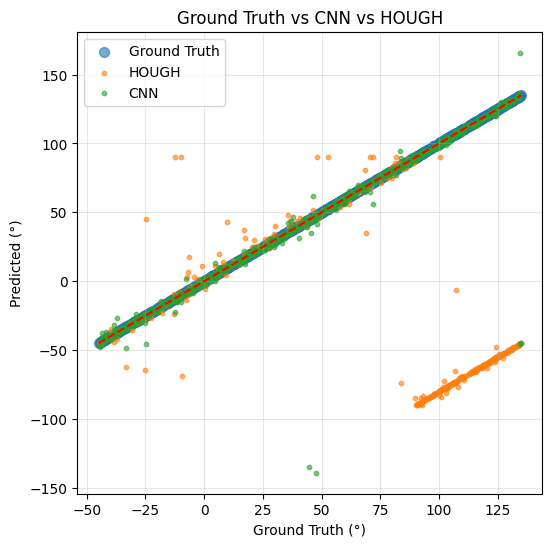

In [35]:
plt.figure(figsize=(6,6))
# plt.scatter(GT_angles, FFT_angles, s=10, alpha=0.6) 
plt.scatter(GT_angles, GT_angles, s=50, alpha=0.6)  # Ground Truth line
plt.scatter(GT_angles, HOUGH_angles, s=10, alpha=0.6)
plt.scatter(GT_angles, CNN_angles, s=10, alpha=0.6)

# mn = min(GT_angles.min(), HOUGH_angles.min(), CNN_angles.min())
# mx = max(GT_angles.max(), HOUGH_angles.max(), CNN_angles.max())

plt.plot([-45,135],[-45,135],'r--')
plt.xlabel("Ground Truth (°)")
plt.ylabel("Predicted (°)")
plt.title("Ground Truth vs CNN vs HOUGH")
plt.legend(["Ground Truth", "HOUGH","CNN"])
plt.grid(alpha=0.3)
plt.show()

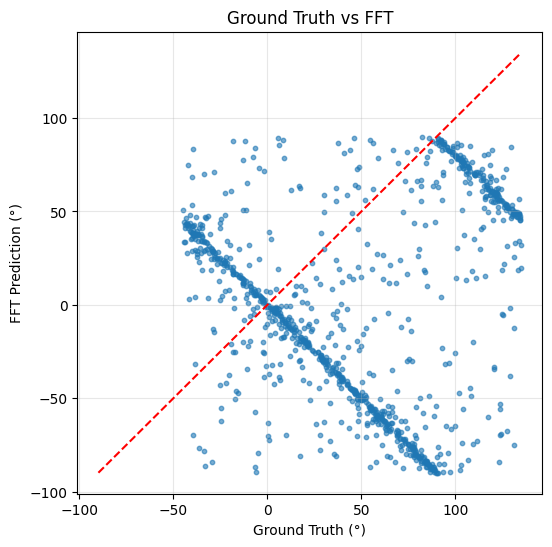

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(GT_angles, FFT_angles, s=10, alpha=0.6)

mn = min(GT_angles.min(), FFT_angles.min())
mx = max(GT_angles.max(), FFT_angles.max())

plt.plot([mn,mx],[mn,mx],'r--')
plt.xlabel("Ground Truth (°)")
plt.ylabel("FFT Prediction (°)")
plt.title("Ground Truth vs FFT")
plt.grid(alpha=0.3)
plt.show()

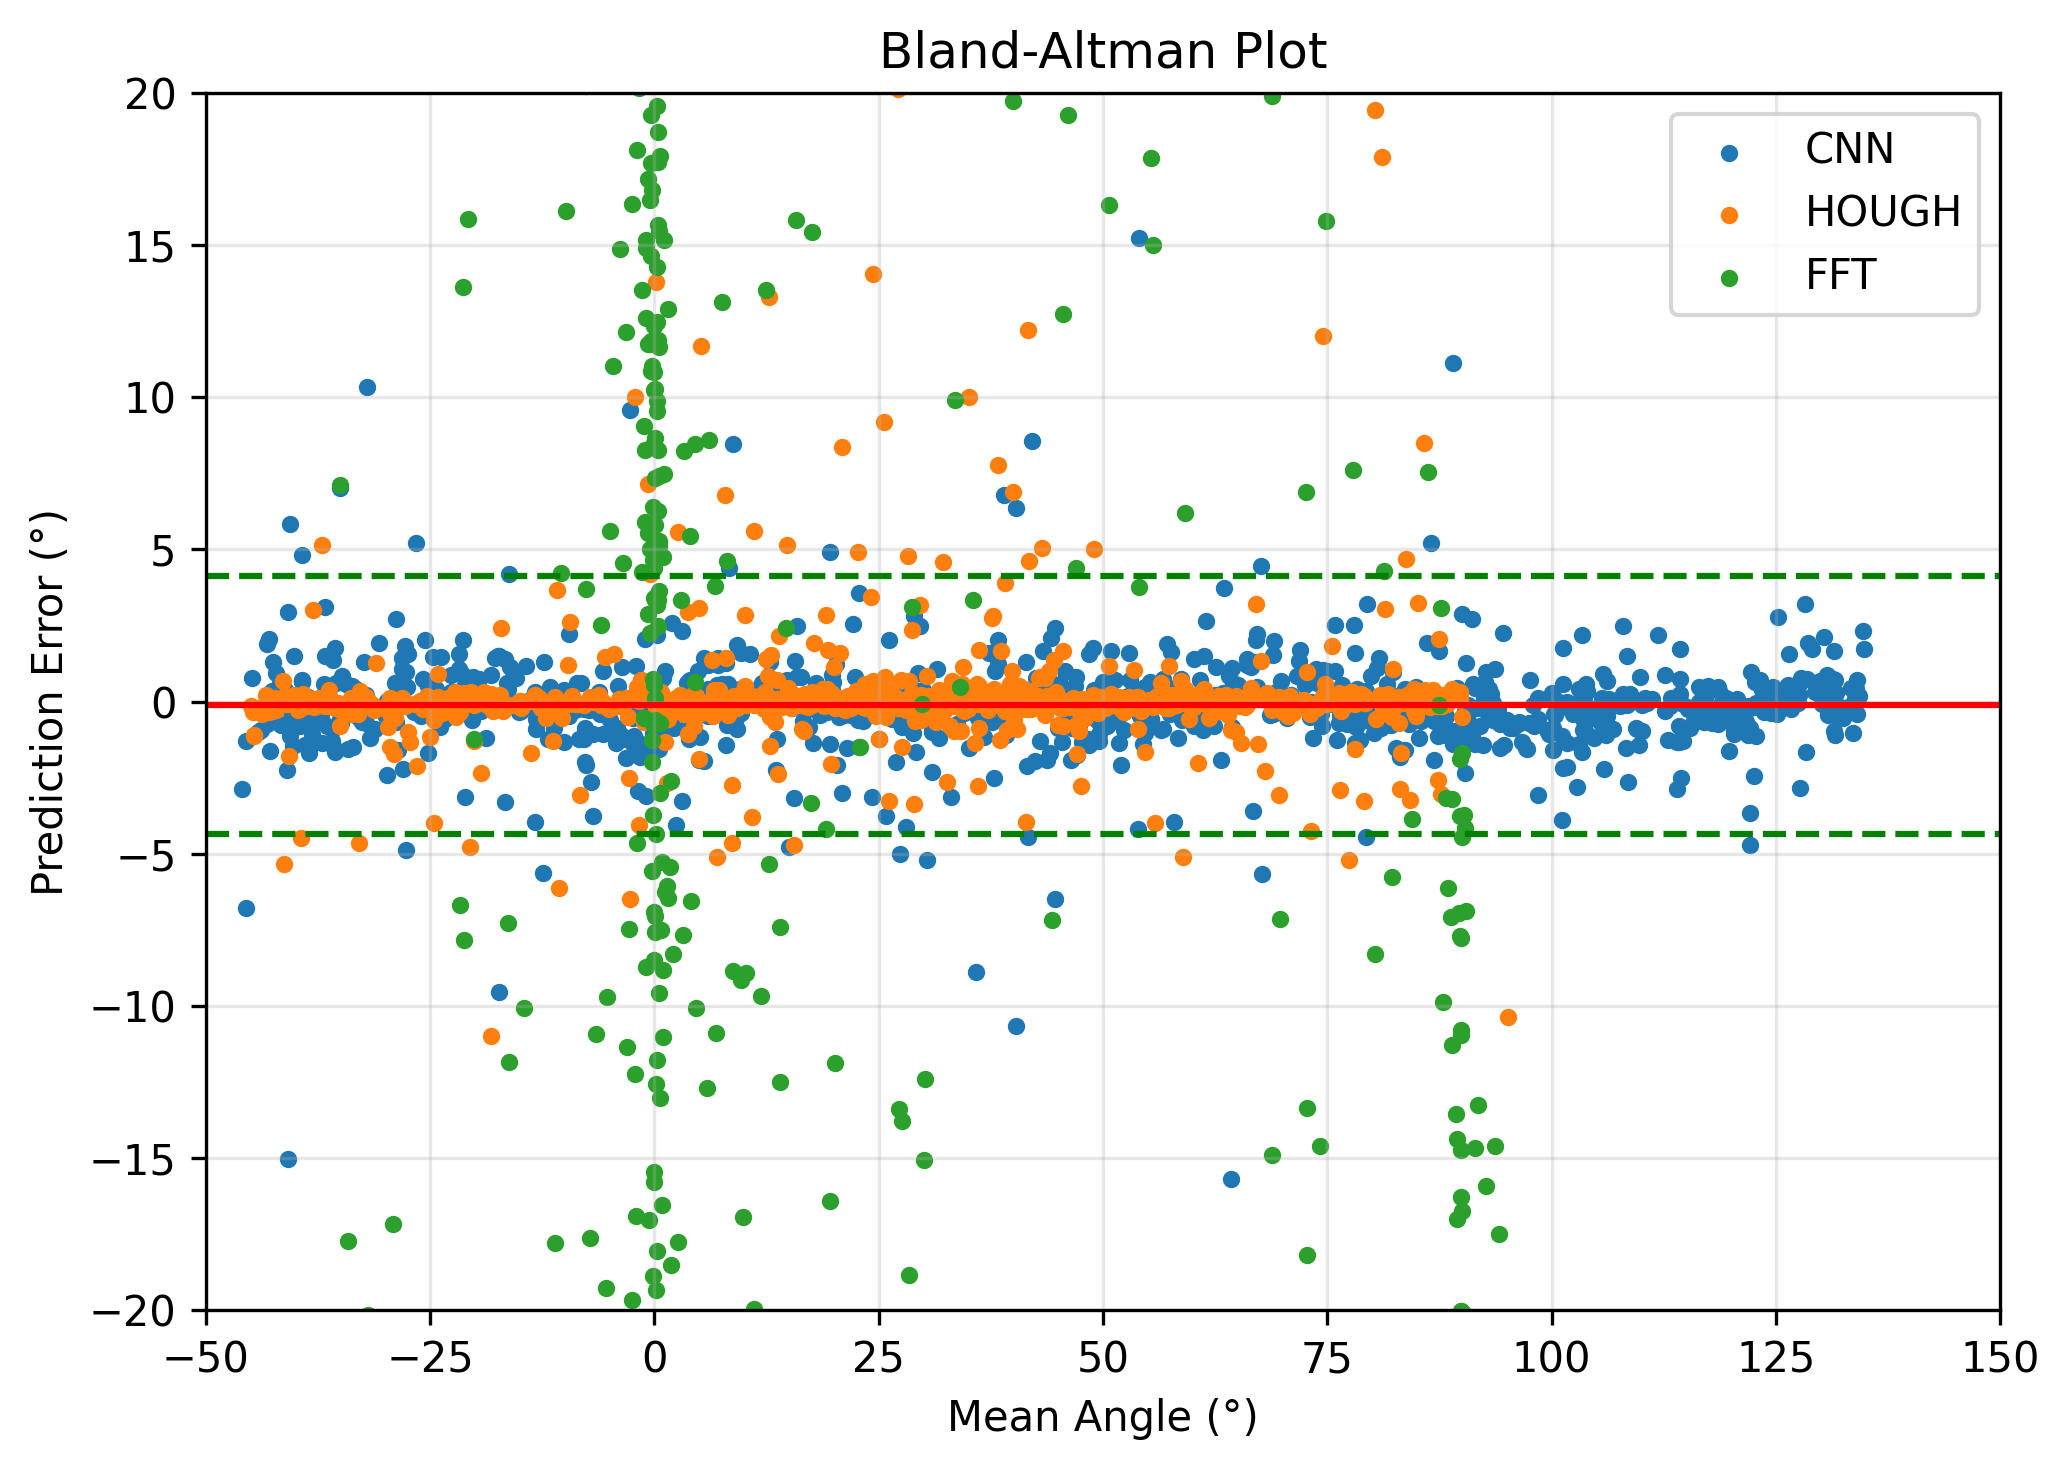

In [57]:
mean_CNN = (GT_angles + CNN_angles)/2
diff_CNN = err_CNN     
mean_Hough = (GT_angles + HOUGH_angles)/2
diff_Hough = err_Hough
mean_FFT = (GT_angles + FFT_angles)/2
diff_FFT = err_FFT              
plt.figure(figsize=(7, 5), dpi=300)
plt.scatter(mean_CNN, diff_CNN, s=10)
plt.scatter(mean_Hough, diff_Hough, s=10)
plt.scatter(mean_FFT, diff_FFT, s=10)

m = np.mean(diff_CNN)
sd = np.std(diff_CNN)

plt.axhline(m, color='red')
plt.axhline(m+1.96*sd, color='green', linestyle='--')
plt.axhline(m-1.96*sd, color='green', linestyle='--')
plt.ylim(-20, 20)
plt.xlim(-50, 150)
plt.xlabel("Mean Angle (°)")
plt.ylabel("Prediction Error (°)")
plt.title("Bland-Altman Plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend(["CNN", "HOUGH", "FFT"])
plt.savefig("bland_altman_plot.pdf", bbox_inches="tight")
plt.show()

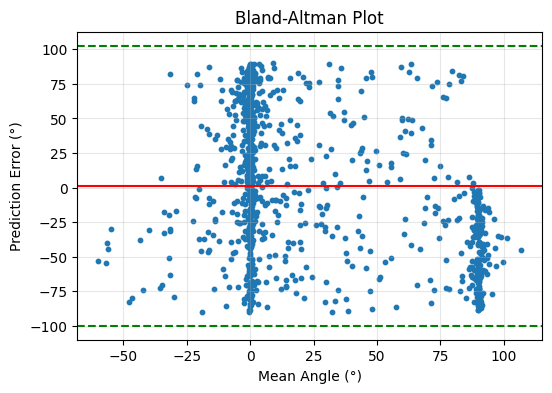

In [13]:
mean = (GT_angles + FFT_angles)/2
diff = err_FFT      

plt.figure(figsize=(6,4))
plt.scatter(mean, diff, s=10)

m = np.mean(diff)
sd = np.std(diff)

plt.axhline(m, color='red')
plt.axhline(m+1.96*sd, color='green', linestyle='--')
plt.axhline(m-1.96*sd, color='green', linestyle='--')

plt.xlabel("Mean Angle (°)")
plt.ylabel("Prediction Error (°)")
plt.title("Bland-Altman Plot")
plt.grid(alpha=0.3)
plt.show()

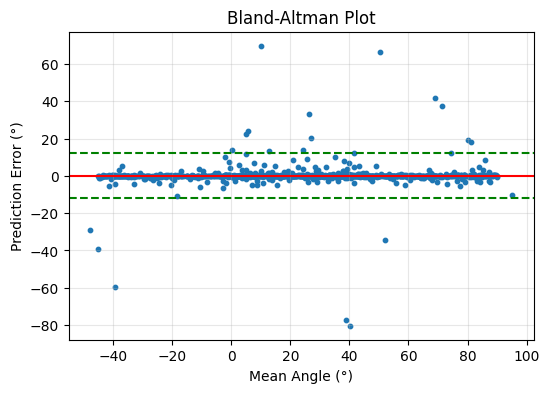

In [14]:
mean = (GT_angles + HOUGH_angles)/2
diff = err_Hough     

plt.figure(figsize=(6,4))
plt.scatter(mean, diff, s=10)

m = np.mean(diff)
sd = np.std(diff)

plt.axhline(m, color='red')
plt.axhline(m+1.96*sd, color='green', linestyle='--')
plt.axhline(m-1.96*sd, color='green', linestyle='--')

plt.xlabel("Mean Angle (°)")
plt.ylabel("Prediction Error (°)")
plt.title("Bland-Altman Plot")
plt.grid(alpha=0.3)
plt.show()

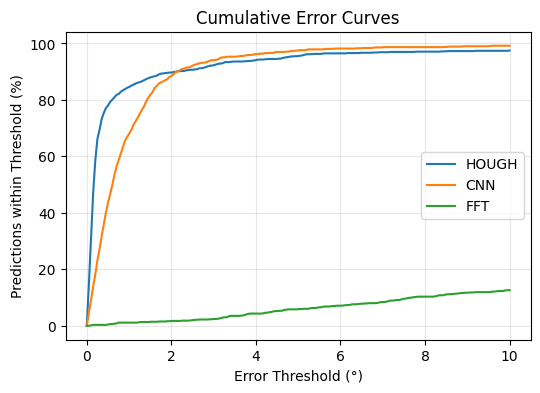

In [39]:
thresholds = np.linspace(0,10,200)

accuracy_Hough = [
    np.mean(np.abs(err_Hough) <= t)*100
    for t in thresholds
]
accuracy_CNN = [
    np.mean(np.abs(err_CNN) <= t)*100
    for t in thresholds
]
accuracy_FFT = [
    np.mean(np.abs(err_FFT) <= t)*100
    for t in thresholds
]
plt.figure(figsize=(6,4))
plt.plot(thresholds, accuracy_Hough, label="HOUGH")
plt.plot(thresholds, accuracy_CNN, label="CNN")
plt.plot(thresholds, accuracy_FFT, label="FFT")

plt.xlabel("Error Threshold (°)")
plt.ylabel("Predictions within Threshold (%)")
plt.title("Cumulative Error Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

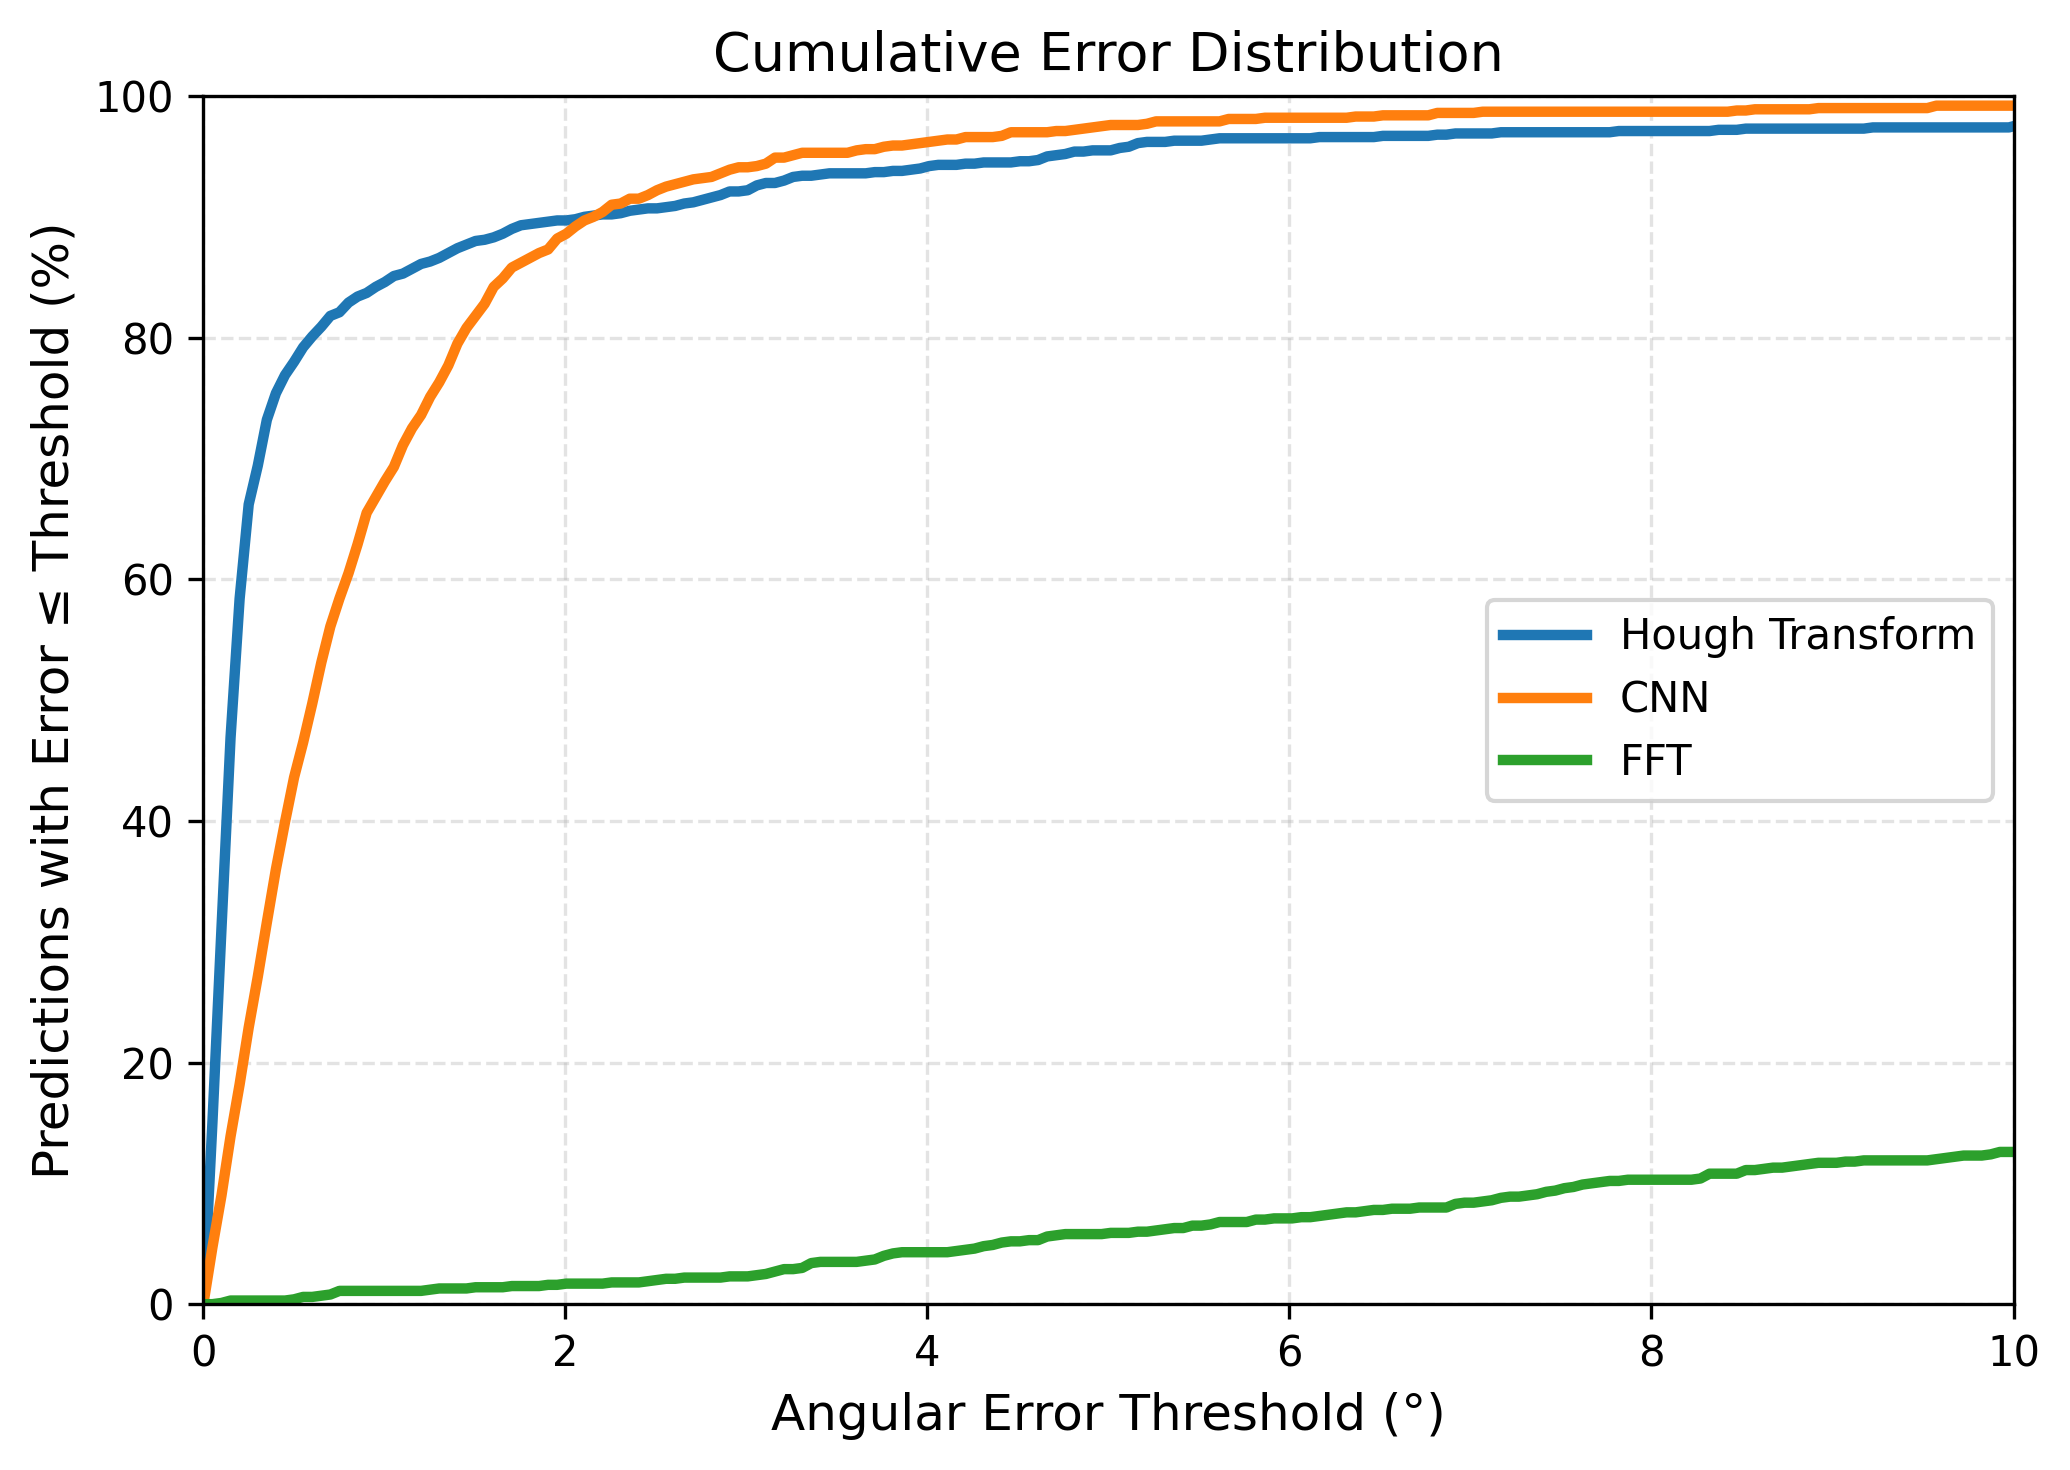

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Cumulative Error Curves
# ---------------------------------------------------------

thresholds = np.linspace(0, 20, 400)   # Extend to 20°

accuracy_Hough = [
    np.mean(np.abs(err_Hough) <= t) * 100
    for t in thresholds
]

accuracy_CNN = [
    np.mean(np.abs(err_CNN) <= t) * 100
    for t in thresholds
]

accuracy_FFT = [
    np.mean(np.abs(err_FFT) <= t) * 100
    for t in thresholds
]

plt.figure(figsize=(7, 5), dpi=300)

plt.plot(
    thresholds,
    accuracy_Hough,
    linewidth=2.5,
    label="Hough Transform"
)

plt.plot(
    thresholds,
    accuracy_CNN,
    linewidth=2.5,
    label="CNN"
)

plt.plot(
    thresholds,
    accuracy_FFT,
    linewidth=2.5,
    label="FFT"
)

plt.xlim(0, 10)
plt.ylim(0, 100)

plt.xlabel("Angular Error Threshold (°)", fontsize=12)
plt.ylabel("Predictions with Error ≤ Threshold (%)", fontsize=12)
plt.title("Cumulative Error Distribution", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig("cumulative_error_curve.pdf", bbox_inches="tight")
plt.savefig("cumulative_error_curve.svg", bbox_inches="tight")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_5808\355610152.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


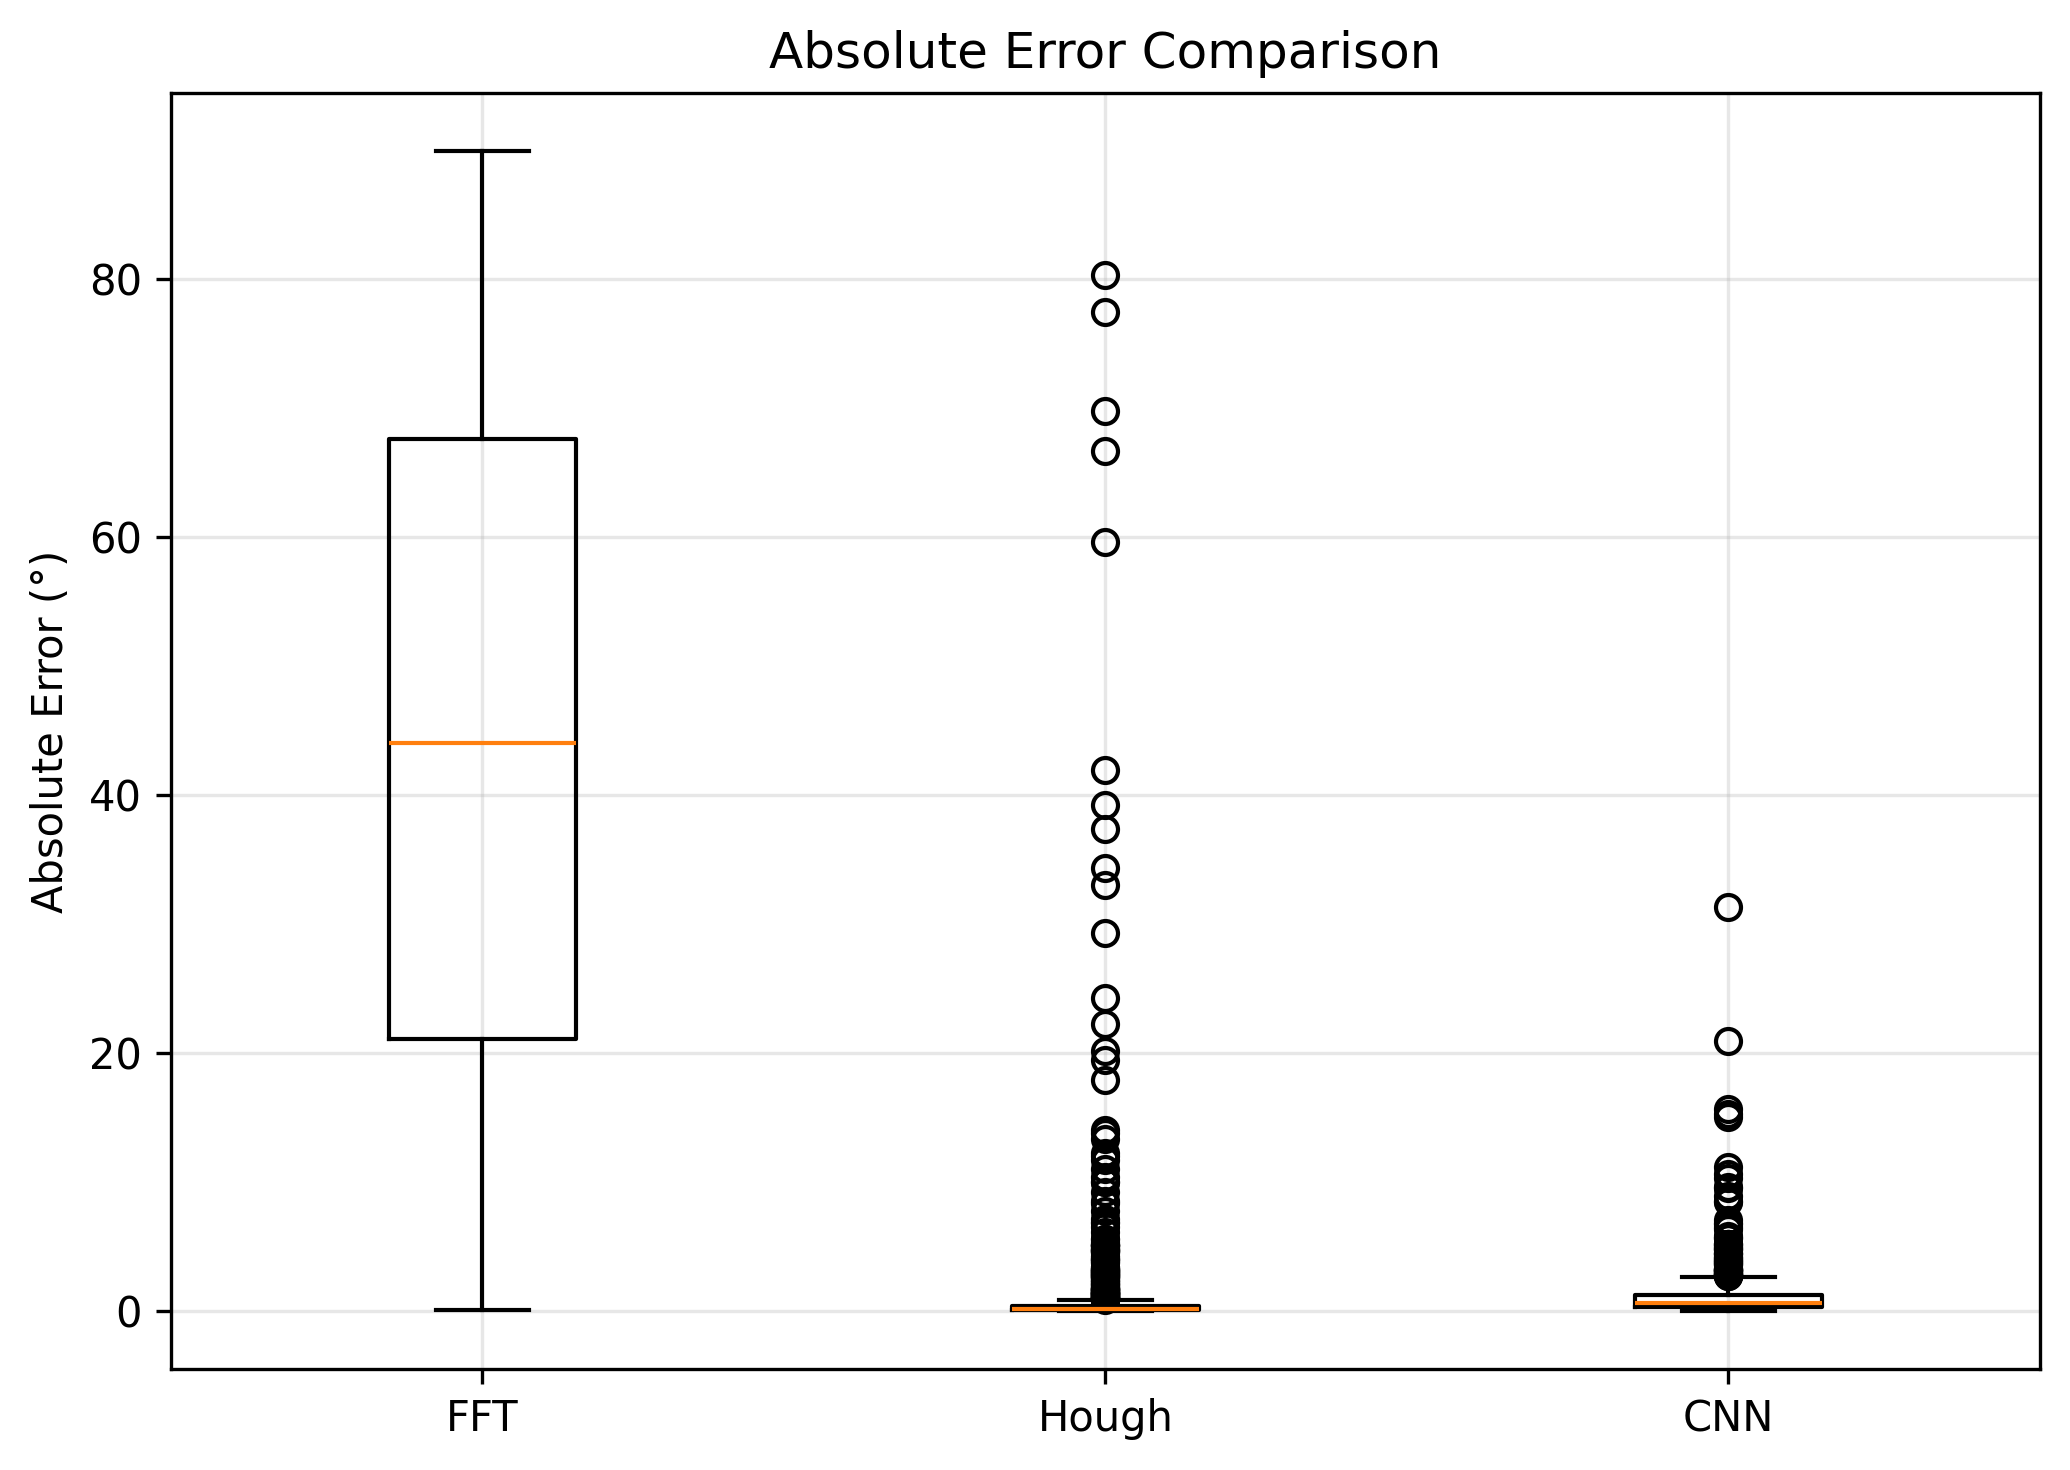

In [47]:
plt.figure(figsize=(7, 5), dpi=300)
plt.boxplot([
    np.abs(err_FFT),
    np.abs(err_Hough),
    np.abs(err_CNN)
], labels=["FFT","Hough","CNN"])

plt.ylabel("Absolute Error (°)")
plt.title("Absolute Error Comparison")
plt.grid(alpha=0.3) 
plt.tight_layout()
plt.savefig("absolute_error_comparison.pdf", bbox_inches="tight")
plt.show()

In [1]:
import pandas as pd
import numpy as np

FFT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_FFT2\images\angles.csv"
HOUGH_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_hough2\images\angles.csv"
GT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\labels.csv"
CNN_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_cnn\angles.csv"

# Read CSVs
fft = pd.read_csv(FFT_ROOT)
hough = pd.read_csv(HOUGH_ROOT)
cnn = pd.read_csv(CNN_ROOT)
gt = pd.read_csv(GT_ROOT)

print(gt.columns)
print(fft.columns)
print(hough.columns)
print(cnn.columns)

Index(['filename', 'angle_deg', 'n_fringes'], dtype='object')
Index(['image', 'fringe_angle_deg', 'rotation_deg'], dtype='object')
Index(['image', 'fringe_angle_deg', 'vertical_error_deg', 'rotation_deg'], dtype='object')
Index(['image', 'original_image', 'predicted_angle'], dtype='object')


In [2]:
# Ground truth
gt = gt.rename(columns={
    "filename": "image",
    "angle_deg": "GT"
})

# FFT
fft = fft.rename(columns={
    "fringe_angle_deg": "FFT"
})

# Hough
hough = hough.rename(columns={
    "fringe_angle_deg": "Hough"
})

# CNN
cnn = cnn.rename(columns={
    "predicted_angle": "CNN"
})

In [3]:
print(gt.columns)
print(fft.columns)
print(hough.columns)
print(cnn.columns)

Index(['image', 'GT', 'n_fringes'], dtype='object')
Index(['image', 'FFT', 'rotation_deg'], dtype='object')
Index(['image', 'Hough', 'vertical_error_deg', 'rotation_deg'], dtype='object')
Index(['image', 'original_image', 'CNN'], dtype='object')


In [4]:
print(gt["image"].head())
print(fft["image"].head())
print(hough["image"].head())
print(cnn["image"].head())

0    img_000000.png
1    img_000001.png
2    img_000002.png
3    img_000003.png
4    img_000004.png
Name: image, dtype: object
0    img_000000.png
1    img_000001.png
2    img_000002.png
3    img_000003.png
4    img_000004.png
Name: image, dtype: object
0    img_000000.png
1    img_000001.png
2    img_000002.png
3    img_000003.png
4    img_000004.png
Name: image, dtype: object
0    img_000000_aligned.png
1    img_000001_aligned.png
2    img_000002_aligned.png
3    img_000003_aligned.png
4    img_000004_aligned.png
Name: image, dtype: object


In [5]:
cnn["image"] = cnn["image"].str.replace(
    "_aligned.png",
    ".png",
    regex=False
)

In [6]:
print(cnn["image"].head())

0    img_000000.png
1    img_000001.png
2    img_000002.png
3    img_000003.png
4    img_000004.png
Name: image, dtype: object


In [7]:
df = (
    gt[["image", "GT", "n_fringes"]]
    .merge(fft[["image", "FFT"]], on="image")
    .merge(hough[["image", "Hough"]], on="image")
    .merge(cnn[["image", "CNN"]], on="image")
)

In [8]:
print(df.head())
print(df.shape)

            image         GT  n_fringes        FFT      Hough        CNN
0  img_000000.png  84.499060  35.157888  -5.342614  -8.382112  82.908264
1  img_000001.png  54.947243  33.988348 -33.527731 -35.056203  55.603302
2  img_000002.png -44.076990   6.799576  56.567886  44.817946 -42.171204
3  img_000003.png  39.428015   3.686197  77.842099 -45.959922  39.886765
4  img_000004.png  22.459130   5.097633 -39.157004 -64.114938  19.440353
(1000, 6)


In [9]:
import numpy as np

def angular_error(pred, gt):
    return (pred - gt + 90) % 180 - 90

In [10]:
df["FFT_Error"] = angular_error(df["FFT"], df["GT"])
df["Hough_Error"] = angular_error(df["Hough"], df["GT"])
df["CNN_Error"] = angular_error(df["CNN"], df["GT"])

In [11]:
print(df[[
    "image",
    "GT",
    "FFT", "FFT_Error",
    "Hough", "Hough_Error",
    "CNN", "CNN_Error"
]].head())

            image         GT        FFT  FFT_Error      Hough  Hough_Error  \
0  img_000000.png  84.499060  -5.342614 -89.841673  -8.382112    87.118828   
1  img_000001.png  54.947243 -33.527731 -88.474974 -35.056203    89.996554   
2  img_000002.png -44.076990  56.567886 -79.355124  44.817946    88.894937   
3  img_000003.png  39.428015  77.842099  38.414084 -45.959922   -85.387938   
4  img_000004.png  22.459130 -39.157004 -61.616134 -64.114938   -86.574068   

         CNN  CNN_Error  
0  82.908264  -1.590795  
1  55.603302   0.656059  
2 -42.171204   1.905787  
3  39.886765   0.458749  
4  19.440353  -3.018776  


In [12]:
df["FFT_GT"] = df["FFT"] + 90
df["Hough_GT"] = df["Hough"] + 90

In [13]:
def wrap180(x):
    return ((x + 90) % 180) - 90

df["FFT_GT"] = wrap180(df["FFT_GT"])
df["Hough_GT"] = wrap180(df["Hough_GT"])

In [14]:
df["FFT_Error"] = angular_error(df["FFT_GT"], df["GT"])
df["Hough_Error"] = angular_error(df["Hough_GT"], df["GT"])

In [15]:
print(df[["GT", "FFT", "FFT_GT", "FFT_Error"]].head())

          GT        FFT     FFT_GT  FFT_Error
0  84.499060  -5.342614  84.657386   0.158327
1  54.947243 -33.527731  56.472269   1.525026
2 -44.076990  56.567886 -33.432114  10.644876
3  39.428015  77.842099 -12.157901 -51.585916
4  22.459130 -39.157004  50.842996  28.383866


In [16]:
print(df[["GT", "FFT", "Hough", "CNN"]].head(10))

           GT        FFT      Hough         CNN
0   84.499060  -5.342614  -8.382112   82.908264
1   54.947243 -33.527731 -35.056203   55.603302
2  -44.076990  56.567886  44.817946  -42.171204
3   39.428015  77.842099 -45.959922   39.886765
4   22.459130 -39.157004 -64.114938   19.440353
5   -0.397593 -79.886368  89.665576   -3.326675
6  -39.987920  51.709450  50.031724  -40.108932
7  123.846853  33.654486  33.951680  123.491333
8  131.665398  56.971155  41.999984  131.269806
9   61.148879 -33.129698 -28.878329   60.841095


In [17]:
print(fft[["FFT", "rotation_deg"]].head(10))
print(hough[["Hough", "rotation_deg"]].head(10))

         FFT  rotation_deg
0  -5.342614     84.657386
1 -33.527731     56.472269
2  56.567886    -33.432114
3  77.842099    -12.157901
4 -39.157004     50.842996
5 -79.886368     10.113632
6  51.709450    -38.290550
7  33.654486    -56.345514
8  56.971155    -33.028845
9 -33.129698     56.870302
       Hough  rotation_deg
0  -8.382112     81.617888
1 -35.056203     54.943797
2  44.817946    -45.182054
3 -45.959922     44.040078
4 -64.114938     25.885062
5  89.665576     -0.334424
6  50.031724    -39.968276
7  33.951680    -56.048320
8  41.999984    -48.000016
9 -28.878329     61.121671


In [18]:
import numpy as np

def ang_err(pred, gt):
    return (pred - gt + 90) % 180 - 90

candidates = {
    "theta": df["FFT"],
    "theta+90": ((df["FFT"] + 90 + 90) % 180) - 90,
    "90-theta": ((90 - df["FFT"] + 90) % 180) - 90,
    "-theta": ((-df["FFT"] + 90) % 180) - 90,
    "theta-90": ((df["FFT"] - 90 + 90) % 180) - 90,
}

for name, pred in candidates.items():
    mae = np.mean(np.abs(ang_err(pred, df["GT"])))
    print(f"{name:10s}: {mae:.3f}°")

theta     : 75.027°
theta+90  : 14.973°
90-theta  : 44.451°
-theta    : 45.549°
theta-90  : 14.973°


In [19]:
import cv2
import numpy as np


def estimate_fringe_angle_fft(gray,
                              dc_radius_ratio=0.05,
                              blur_sigma=3):
    """
    Estimate fringe orientation from the dominant FFT peak.

    Returns
    -------
    angle : float
        Fringe angle in the same convention as the ground truth
        (-90° to +90°).
    """

    img = gray.astype(np.float32)

    # Remove DC
    img -= img.mean()

    h, w = img.shape

    # Hann window
    window = np.outer(np.hanning(h), np.hanning(w))
    img *= window

    # FFT
    F = np.fft.fftshift(np.fft.fft2(img))
    mag = np.abs(F)

    # Log magnitude
    mag = np.log1p(mag)

    # Smooth slightly
    mag = cv2.GaussianBlur(mag, (0, 0), blur_sigma)

    # Remove DC
    cy, cx = h // 2, w // 2
    r = int(min(h, w) * dc_radius_ratio)

    mag[cy-r:cy+r+1, cx-r:cx+r+1] = 0

    # Strongest peak
    py, px = np.unravel_index(np.argmax(mag), mag.shape)

    dx = px - cx
    dy = py - cy

    # Frequency direction
    freq_angle = np.degrees(np.arctan2(dy, dx))

    # Fringe direction
    fringe_angle = freq_angle + 90

    # Normalize to [-90,90]
    fringe_angle = ((fringe_angle + 90) % 180) - 90

    return float(fringe_angle)

In [20]:
img = cv2.imread(
    r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images\img_000000.png",
    cv2.IMREAD_GRAYSCALE
)

angle = estimate_fringe_angle_fft(img)

print(angle)

-4.899092453787773


In [21]:
print(df.loc[df["image"]=="img_000000.png","GT"].iloc[0])

84.4990595776847


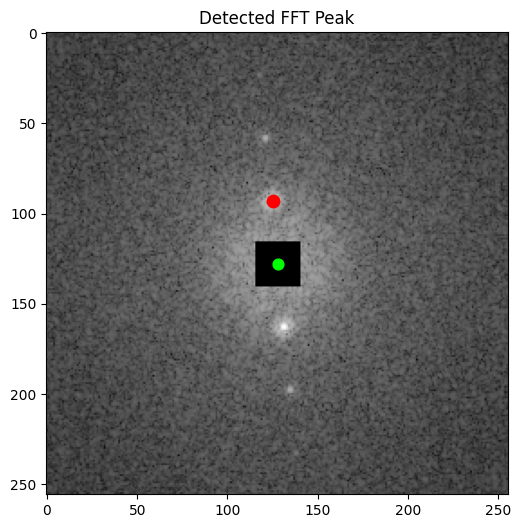

dx = -3
dy = -35
Frequency angle = -94.89909245378777


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(
    r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images\img_000000.png",
    cv2.IMREAD_GRAYSCALE,
).astype(np.float32)

img -= img.mean()

window = np.outer(np.hanning(img.shape[0]), np.hanning(img.shape[1]))
img *= window

F = np.fft.fftshift(np.fft.fft2(img))
mag = np.log1p(np.abs(F))

h, w = mag.shape
cy, cx = h // 2, w // 2

r = int(min(h, w) * 0.05)
mag[cy-r:cy+r+1, cx-r:cx+r+1] = 0

py, px = np.unravel_index(np.argmax(mag), mag.shape)

plt.figure(figsize=(6,6))
plt.imshow(mag, cmap="gray")
plt.scatter(px, py, c="red", s=80)
plt.scatter(cx, cy, c="lime", s=60)
plt.title("Detected FFT Peak")
plt.show()

dx = px - cx
dy = py - cy

print("dx =", dx)
print("dy =", dy)
print("Frequency angle =", np.degrees(np.arctan2(dy, dx)))

In [23]:
def wrap180(theta):
    return ((theta + 90) % 180) - 90

df["FFT_GT"] = wrap180(90 - df["FFT"])
df["Hough_GT"] = wrap180(90 - df["Hough"])

In [24]:
df["FFT_Error"] = angular_error(df["FFT_GT"], df["GT"])
df["Hough_Error"] = angular_error(df["Hough_GT"], df["GT"])

In [25]:
print(df[[
    "GT",
    "FFT",
    "FFT_GT",
    "FFT_Error"
]].head(10))

print("FFT MAE:",
      np.mean(np.abs(df["FFT_Error"])))

           GT        FFT     FFT_GT  FFT_Error
0   84.499060  -5.342614 -84.657386  10.843554
1   54.947243 -33.527731 -56.472269  68.580487
2  -44.076990  56.567886  33.432114  77.509104
3   39.428015  77.842099  12.157901 -27.270114
4   22.459130 -39.157004 -50.842996 -73.302125
5   -0.397593 -79.886368 -10.113632  -9.716038
6  -39.987920  51.709450  38.290550  78.278471
7  123.846853  33.654486  56.345514 -67.501339
8  131.665398  56.971155  33.028845  81.363448
9   61.148879 -33.129698 -56.870302  61.980819
FFT MAE: 44.45103797093364
